# Qwen-Image Layered RGBA VAE Reconstruction

This notebook reconstructs an RGBA image using only the Qwen-Image-Layered VAE.
Set `INPUT_PATH` and run all cells.


In [ ]:
import os
import math
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from IPython.display import display

from diffsynth.pipelines.qwen_image import ModelConfig, QwenImagePipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
LOW_VRAM = False
ALPHA_IN_MINUS1_1 = False


def _find_repo_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "diffsynth").exists() and (parent / "pyproject.toml").exists():
            return parent
    return start


def _resolve_model_base(repo_root: Path) -> Path:
    env = os.environ.get("DIFFSYNTH_MODEL_BASE_PATH", "/mnt/local/diffsynth_models")
    if env:
        return Path(env)
    candidates = [
        repo_root / "diffsynth_models",
        Path("/mnt/lica-data-2/for_jjseol/diffsynth_models"),
        Path("/mnt/data/for_jjseol/diffsynth_models"),
    ]
    for cand in candidates:
        if (cand / "Qwen").exists():
            return cand
    return candidates[0]


def _build_vram_config(device: str, *, low_vram: bool) -> dict:
    if device == "cuda" and low_vram:
        return {
            "offload_dtype": "disk",
            "offload_device": "disk",
            "onload_dtype": torch.float8_e4m3fn,
            "onload_device": "cpu",
            "preparing_dtype": torch.float8_e4m3fn,
            "preparing_device": "cuda",
            "computation_dtype": torch.bfloat16,
            "computation_device": "cuda",
        }
    if device == "cuda":
        return {
            "offload_dtype": None,
            "offload_device": None,
            "onload_dtype": torch.bfloat16,
            "onload_device": "cuda",
            "preparing_dtype": torch.bfloat16,
            "preparing_device": "cuda",
            "computation_dtype": torch.bfloat16,
            "computation_device": "cuda",
        }
    return {
        "offload_dtype": None,
        "offload_device": None,
        "onload_dtype": torch.float32,
        "onload_device": "cpu",
        "preparing_dtype": torch.float32,
        "preparing_device": "cpu",
        "computation_dtype": torch.float32,
        "computation_device": "cpu",
    }


def _pil_to_input_tensor(
    img: Image.Image,
    *,
    device: str,
    dtype: torch.dtype,
    alpha_in_minus1_1: bool,
) -> torch.Tensor:
    img = img.convert("RGBA")
    arr = np.asarray(img).astype(np.float32) / 255.0
    rgb = arr[..., :3] * 2.0 - 1.0
    alpha = arr[..., 3:4]
    if alpha_in_minus1_1:
        alpha = alpha * 2.0 - 1.0
    stacked = np.concatenate([rgb, alpha], axis=-1)
    tensor = torch.from_numpy(stacked).permute(2, 0, 1).unsqueeze(0)
    return tensor.to(device=device, dtype=dtype)


def _tensor_to_rgba_pil(x: torch.Tensor, *, alpha_in_minus1_1: bool) -> Image.Image:
    if x.ndim == 5:
        x = x[:, :, 0, :, :]
    x = x[0].permute(1, 2, 0).detach().float().cpu().numpy()
    rgb = (np.clip(x[..., :3], -1.0, 1.0) + 1.0) * 0.5
    alpha = x[..., 3:4]
    if alpha_in_minus1_1:
        alpha = (np.clip(alpha, -1.0, 1.0) + 1.0) * 0.5
    else:
        alpha = np.clip(alpha, 0.0, 1.0)
    rgba = np.concatenate([rgb, alpha], axis=-1)
    return Image.fromarray((rgba * 255).astype(np.uint8), mode="RGBA")


In [ ]:
REPO_ROOT = _find_repo_root(Path(".").resolve())
MODEL_BASE = _resolve_model_base(REPO_ROOT)
VAE_PATH = MODEL_BASE / "Qwen" / "Qwen-Image-Layered" / "vae" / "diffusion_pytorch_model.safetensors"
if not VAE_PATH.exists():
    raise FileNotFoundError(f"VAE not found at {VAE_PATH}")

vram_config = _build_vram_config(DEVICE, low_vram=LOW_VRAM)
pipe = QwenImagePipeline.from_pretrained(
    torch_dtype=TORCH_DTYPE,
    device=DEVICE,
    model_configs=[ModelConfig(path=str(VAE_PATH), **vram_config)],
    tokenizer_config=None,
    processor_config=None,
)


Loading models from: "/mnt/local/diffsynth_models/Qwen/Qwen-Image-Layered/vae/diffusion_pytorch_model.safetensors"
Loaded model: {
    "model_name": "qwen_image_vae",
    "model_class": "diffsynth.models.qwen_image_vae.QwenImageVAE",
    "extra_kwargs": {
        "image_channels": 4
    }
}
No qwen_image_text_encoder models available. This is not an error.
No qwen_image_dit models available. This is not an error.
Using qwen_image_vae from "/mnt/local/diffsynth_models/Qwen/Qwen-Image-Layered/vae/diffusion_pytorch_model.safetensors".
No qwen_image_blockwise_controlnet models available. This is not an error.
No siglip2_image_encoder models available. This is not an error.
No dinov3_image_encoder models available. This is not an error.
No qwen_image_image2lora_style models available. This is not an error.
No qwen_image_image2lora_coarse models available. This is not an error.
No qwen_image_image2lora_fine models available. This is not an error.


height % 16 != 0. We round it up to 800.


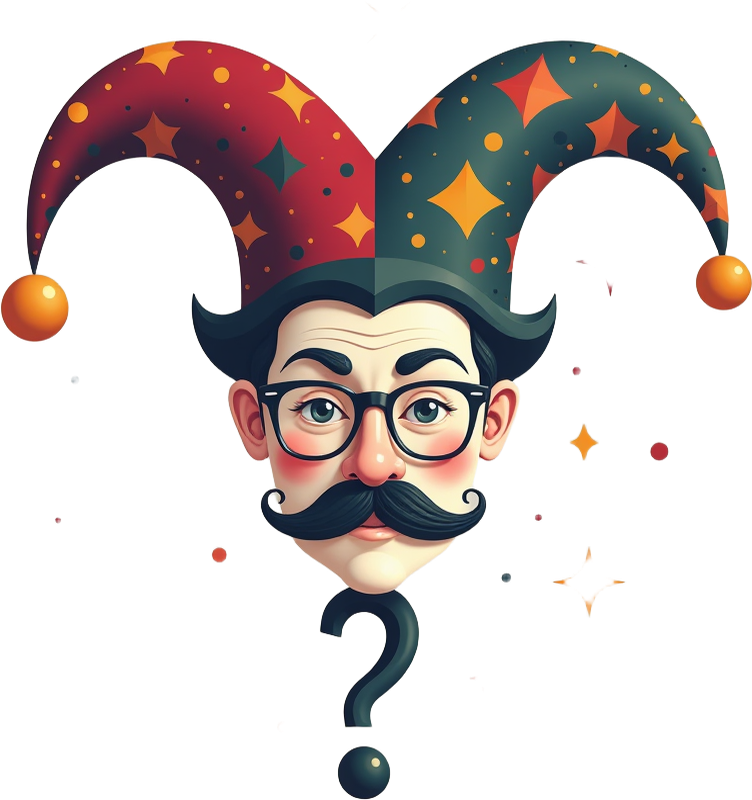

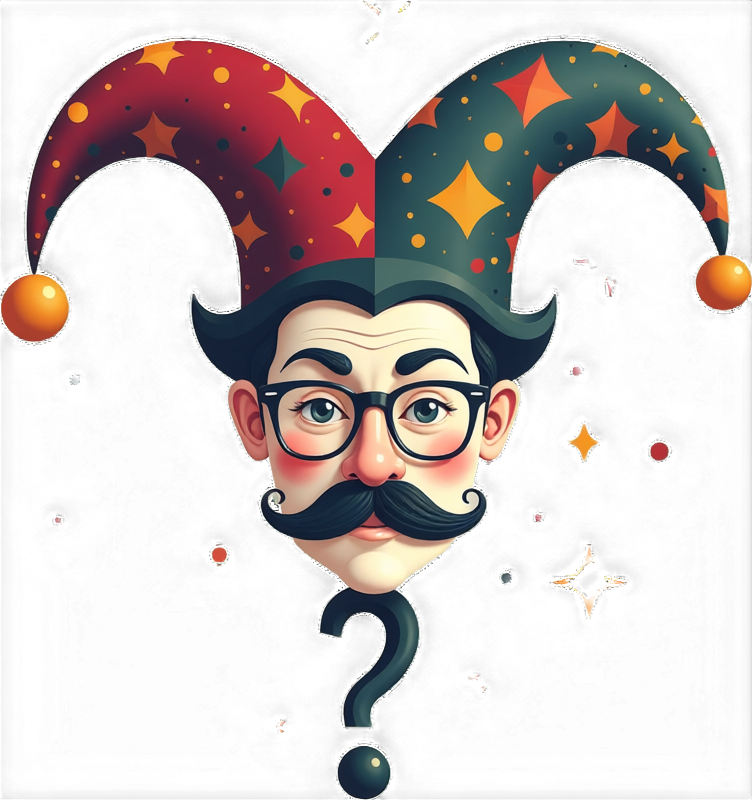

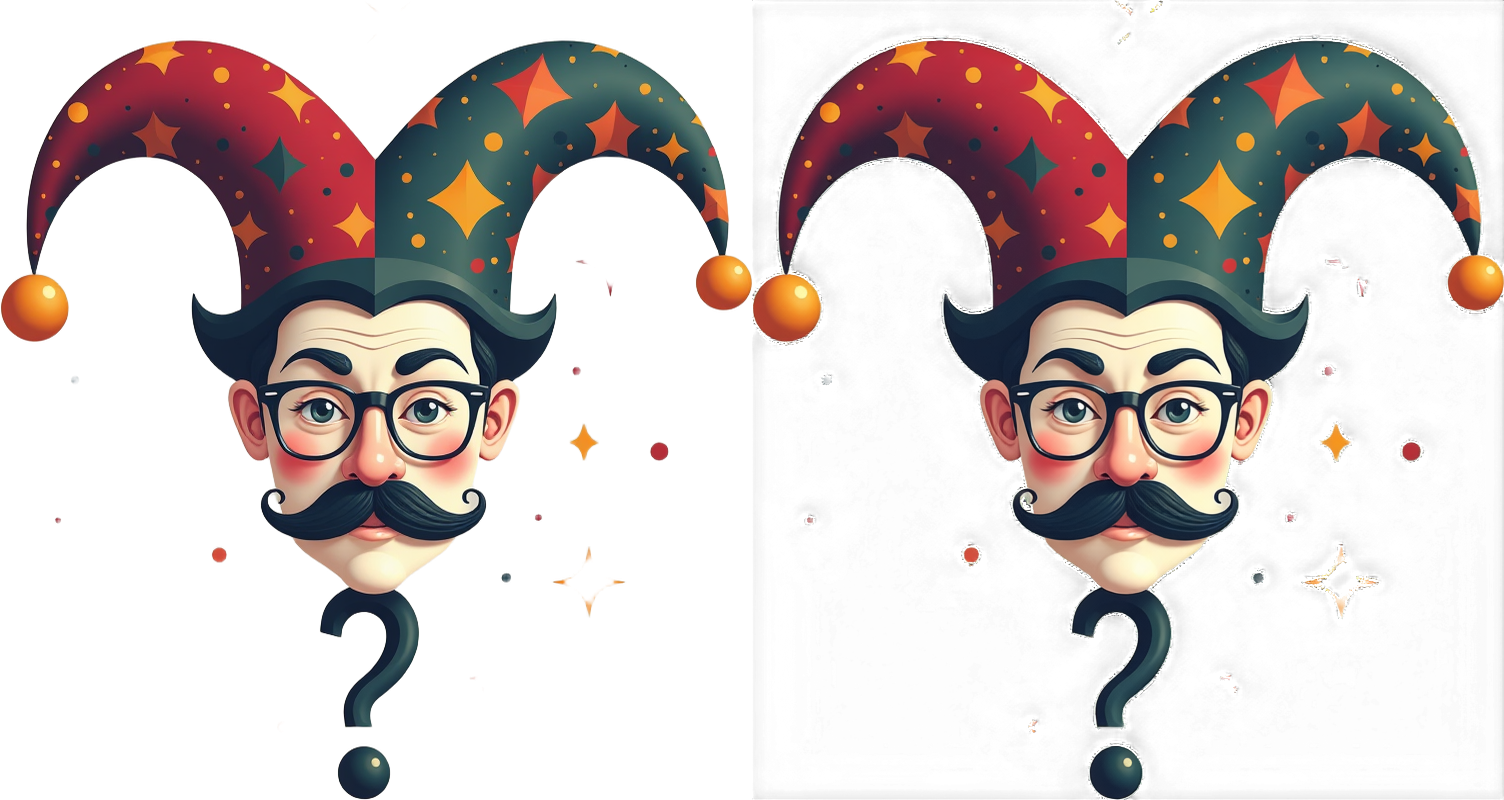

[done] recon saved to /home/ubuntu/DiffSynth-Studio/output/qwen_rgba_vae_recon/image (1)_rgba_vae_recon.png
[done] side-by-side saved to /home/ubuntu/DiffSynth-Studio/output/qwen_rgba_vae_recon/image (1)_rgba_vae_side_by_side.png


In [ ]:
INPUT_PATH = Path("path/to/input.png")
OUTPUT_DIR = REPO_ROOT / "output" / "qwen_rgba_vae_recon"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = OUTPUT_DIR / f"{INPUT_PATH.stem}_rgba_vae_recon.png"
SIDE_BY_SIDE_PATH = OUTPUT_DIR / f"{INPUT_PATH.stem}_rgba_vae_side_by_side.png"

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Input image not found: {INPUT_PATH}")

input_image = Image.open(INPUT_PATH).convert("RGBA")
height, width = pipe.check_resize_height_width(input_image.height, input_image.width)
if (input_image.height, input_image.width) != (height, width):
    input_image = input_image.resize((width, height), Image.LANCZOS)

input_tensor = _pil_to_input_tensor(
    input_image,
    device=DEVICE,
    dtype=TORCH_DTYPE,
    alpha_in_minus1_1=ALPHA_IN_MINUS1_1,
)

with torch.no_grad():
    latents = pipe.vae.encode(input_tensor)
    recon = pipe.vae.decode(latents)

recon_img = _tensor_to_rgba_pil(recon, alpha_in_minus1_1=ALPHA_IN_MINUS1_1)
recon_img.save(OUTPUT_PATH)

canvas = Image.new("RGBA", (input_image.width * 2, input_image.height))
canvas.paste(input_image, (0, 0))
canvas.paste(recon_img, (input_image.width, 0))
canvas.save(SIDE_BY_SIDE_PATH)

display(input_image)
display(recon_img)
display(canvas)

print(f"[done] recon saved to {OUTPUT_PATH}")
print(f"[done] side-by-side saved to {SIDE_BY_SIDE_PATH}")


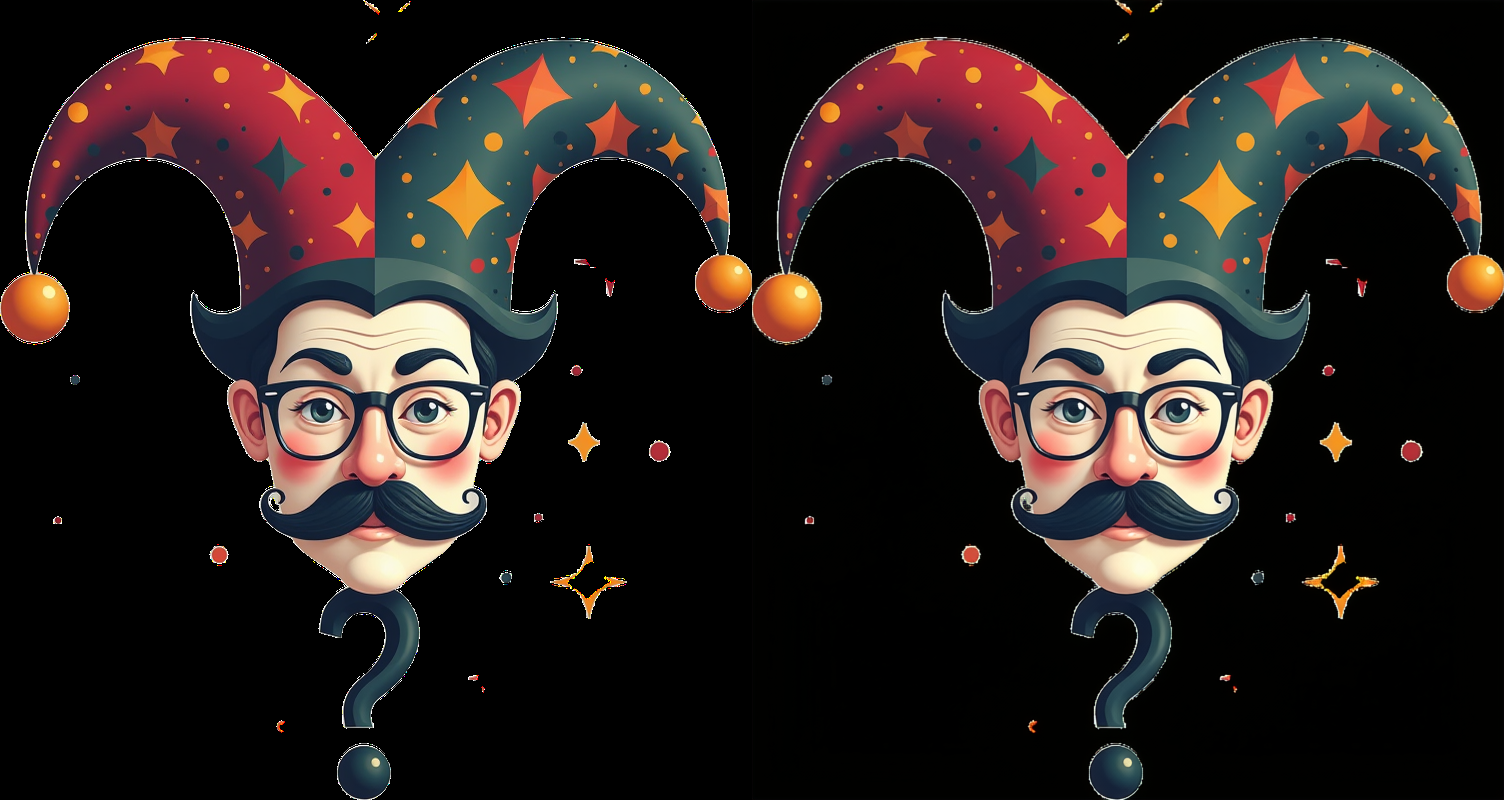

In [9]:
display(canvas.convert("RGB"))#.getchannel(3))